<a href="https://colab.research.google.com/github/Muhammad-AHMAD07/ML_Lab/blob/main/ML(Lab_4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

Data Set Loading

In [2]:
data = pd.read_csv("/content/Housing.csv")
print("First 5 rows of the dataset:")
print(data.head())

First 5 rows of the dataset:
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_ren

Data Pre Processing

In [5]:
X = data[['bedrooms','bathrooms','sqft_living','sqft_lot','floors']]
y = data['price']


print("\nMissing values in the dataset:")
print(data.isnull().sum())


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Missing values in the dataset:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


Model Training

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept (β0):", model.intercept_)
print("Coefficients(β1, β2,..., βn):", model.coef_)


y_pred = model.predict(X_test)

comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(comparison.head())

Intercept (β0): 106289.49963786616
Coefficients(β1, β2,..., βn): [-6.24572555e+04 -9.90845367e+03  3.11085209e+02 -5.98091770e-01
  1.04883794e+04]
      Actual      Predicted
0   544000.0  368343.041263
1        0.0  399643.074319
2  1712500.0  829522.077509
3   365000.0  584626.464126
4   275000.0  434465.244795


Evaluating Model


Model Evaluation Metrics:
Mean Squared Error(MSE): 990083659260.851
R-squared(R²): 0.029183495254359593


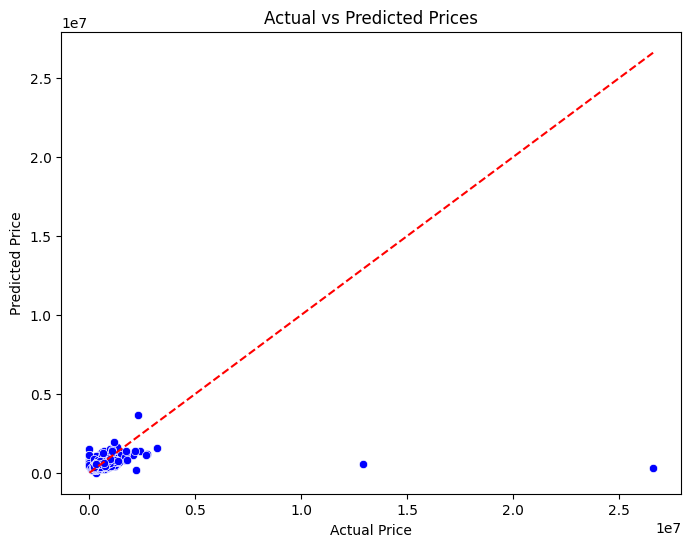

In [8]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print("Mean Squared Error(MSE):", mse)
print("R-squared(R²):", r2)


plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, color="blue")

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()